### 3. Carregamento das Bibliotecas & Dataset

In [ ]:
# Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix


In [22]:
# Carregando o dataset
df = pd.read_csv("C:\\Users\\u513127\\Downloads\\phishing-project-kaggle-main\\phishing-project-kaggle-main\\data\\Phishing_Legitimate_full.csv")

### 4. Análise Exploratória dos Dados (EDA)

**Objetivo**

Esta etapa tem como objetivo compreender a estrutura geral do dataset, incluindo dimensões, tipos de variáveis, qualidade dos dados e distribuição da variável alvo. Essa análise inicial é fundamental para identificar possíveis inconsistências, compreender a natureza dos atributos e direcionar adequadamente as etapas posteriores de pré-processamento e modelagem.

#### 4.1 Estrutura Geral do Dataset

In [ ]:
# 4.1.1 Exibindo as primeiras linhas do dataset
df.head()

,id,NumDots,SubdomainLevel,PathLevel,UrlLength,NumDash,NumDashInHostname,AtSymbol,TildeSymbol,NumUnderscore,...,IframeOrFrame,MissingTitle,ImagesOnlyInForm,SubdomainLevelRT,UrlLengthRT,PctExtResourceUrlsRT,AbnormalExtFormActionR,ExtMetaScriptLinkRT,PctExtNullSelfRedirectHyperlinksRT,CLASS_LABEL
0,1,3,1,5,72,0,0,0,0,0,...,0,0,1,1,0,1,1,-1,1,1
1,2,3,1,3,144,0,0,0,0,2,...,0,0,0,1,-1,1,1,1,1,1
2,3,3,1,2,58,0,0,0,0,0,...,0,0,0,1,0,-1,1,-1,0,1
3,4,3,1,6,79,1,0,0,0,0,...,0,0,0,1,-1,1,1,1,-1,1
4,5,3,0,4,46,0,0,0,0,0,...,1,0,0,1,1,-1,0,-1,-1,1


In [ ]:
# 4.1.2 Exibindo as dimensões do dataset
print("Dimensões do dataset:")
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

Dimensões do dataset:
Linhas: 10000
Colunas: 50


In [ ]:
# 4.1.3 Informações gerais
print("\nInformações gerais do dataset:")
df.info()


Informações gerais do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   id                                  10000 non-null  int64  
 1   NumDots                             10000 non-null  int64  
 2   SubdomainLevel                      10000 non-null  int64  
 3   PathLevel                           10000 non-null  int64  
 4   UrlLength                           10000 non-null  int64  
 5   NumDash                             10000 non-null  int64  
 6   NumDashInHostname                   10000 non-null  int64  
 7   AtSymbol                            10000 non-null  int64  
 8   TildeSymbol                         10000 non-null  int64  
 9   NumUnderscore                       10000 non-null  int64  
 10  NumPercent                          10000 non-null  int64  
 11  NumQueryCo

In [ ]:
# 4.1.4 Tipos das variáveis
print("\nTipos das variáveis:")
print(df.dtypes.value_counts())


Tipos das variáveis:
int64      47
float64     3
Name: count, dtype: int64


In [ ]:
# 4.1.5 Memória utilizada
memory_usage = df.memory_usage(deep=True).sum() / 1024**2

print(f"\nMemória utilizada: {memory_usage:.2f} MB")


Memória utilizada: 3.81 MB


#### 4.2 Qualidade dos Dados

In [37]:
# 4.2.1 Verificação de duplicatas
duplicated = df.duplicated().sum()

print(f"\nQuantidade de registros duplicados: {duplicated}")


Quantidade de registros duplicados: 0


In [38]:
# 4.2.2 Valores ausentes
missing_values = df.isnull().sum()

print("\nValores ausentes por coluna:")
print(missing_values[missing_values > 0])


Valores ausentes por coluna:
Series([], dtype: int64)


#### 4.3 Análise da Variável Target
Neste projeto, a variável alvo (class_label) é representada de forma binária, em que:

- 0 representa URLs legítimas;
- 1 representa URLs classificadas como phishing.

Essa representação binária é adequada para problemas de classificação supervisionada, facilitando a aplicação de algoritmos de Machine Learning voltados para detecção de fraudes e ameaças cibernéticas.

In [ ]:
# 4.3.1 Distribuição da variável alvo
target_distribution = df['CLASS_LABEL'].value_counts()

print("\nDistribuição da variável alvo:")
print(target_distribution)

# Percentual
target_percentage = df['CLASS_LABEL'].value_counts(normalize=True) * 100

print("\nDistribuição percentual:")
print(target_percentage)


Distribuição da variável alvo:
CLASS_LABEL
1    5000
0    5000
Name: count, dtype: int64

Distribuição percentual:
CLASS_LABEL
1    50.0
0    50.0
Name: proportion, dtype: float64


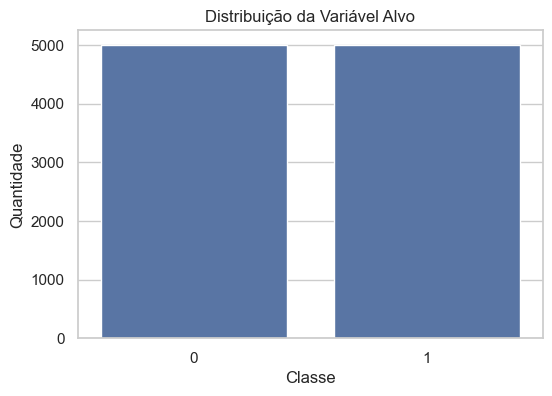

In [ ]:
# 4.3.2 Visualização da distribuição da variável alvo
plt.figure(figsize=(6,4))

sns.countplot(x='CLASS_LABEL', data=df)

plt.title('Distribuição da Variável Alvo')
plt.xlabel('Classe')
plt.ylabel('Quantidade')

plt.show()

O dataset contém aproximadamente 10.000 registros e 50 atributos, apresentando um volume adequado para treinamento e avaliação de modelos de Machine Learning aplicados à detecção de phishing. O conjunto de dados é composto majoritariamente por variáveis numéricas e binárias relacionadas às características estruturais de URLs e páginas web, sendo 47 atributos do tipo int64 e 3 atributos do tipo float64.

A análise inicial demonstra que o conjunto de dados apresenta boa integridade, sem incidência de valores ausentes e sem a presença de registros duplicados, indicando consistência e qualidade adequadas para as etapas subsequentes de análise e modelagem.

Observa-se ainda que a variável alvo apresenta distribuição equilibrada entre as classes legítima (0) e phishing (1), com aproximadamente 5.000 registros para cada categoria. Essa característica é positiva para o treinamento de modelos supervisionados, pois reduz possíveis vieses associados ao desbalanceamento de classes.

Além disso, as variáveis presentes no dataset aparentam representar padrões relevantes relacionados ao comportamento de URLs maliciosas, fornecendo uma base adequada para as etapas subsequentes de análise exploratória, engenharia de atributos e modelagem preditiva.

#### 4.4 Estatísticas Descritivas

In [ ]:
# 4.4.1 Estatísticas descritivas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,10000.0,5000.500000,2886.895680,1.0,2500.750000,5000.500000,7500.250000,10000.0
NumDots,10000.0,2.445100,1.346836,1.0,2.000000,2.000000,3.000000,21.0
SubdomainLevel,10000.0,0.586800,0.751214,0.0,0.000000,1.000000,1.000000,14.0
PathLevel,10000.0,3.300300,1.863241,0.0,2.000000,3.000000,4.000000,18.0
UrlLength,10000.0,70.264100,33.369877,12.0,48.000000,62.000000,84.000000,253.0
NumDash,10000.0,1.818000,3.106258,0.0,0.000000,0.000000,2.000000,55.0
NumDashInHostname,10000.0,0.138900,0.545744,0.0,0.000000,0.000000,0.000000,9.0
AtSymbol,10000.0,0.000300,0.017319,0.0,0.000000,0.000000,0.000000,1.0
TildeSymbol,10000.0,0.013100,0.113709,0.0,0.000000,0.000000,0.000000,1.0
NumUnderscore,10000.0,0.323200,1.114660,0.0,0.000000,0.000000,0.000000,18.0


Algumas variáveis relacionadas à complexidade estrutural das URLs, como `UrlLength`, `PathLength` e `NumNumericChars`, apresentam elevada dispersão e valores máximos significativamente superiores às medianas, sugerindo a presença de URLs extremamente complexas ou atípicas, característica frequentemente associada a tentativas de mascaramento em ataques de phishing.

Observa-se também que diversas variáveis binárias possuem distribuição altamente concentrada em 0, como `AtSymbol`, `FakeLinkInStatusBar`, `PopUpWindow` e `RightClickDisabled`. Isso indica que determinadas técnicas maliciosas aparecem com baixa frequência no conjunto de dados, embora ainda possam representar sinais relevantes para classificação.

Em contrapartida, atributos como `RandomString`, `IframeOrFrame` e `DomainInPaths` apresentam distribuição mais equilibrada entre presença e ausência, sugerindo maior potencial discriminatório entre URLs legítimas e maliciosas.

Algumas variáveis derivadas, como `UrlLengthRT`, `PctExtResourceUrlsRT` e `SubdomainLevelRT`, utilizam codificação trivalorada (-1, 0 e 1), indicando que determinados atributos passaram por processos adicionais de categorização ou normalização baseados em regras heurísticas.

#### 4.5 Distribuição das Features

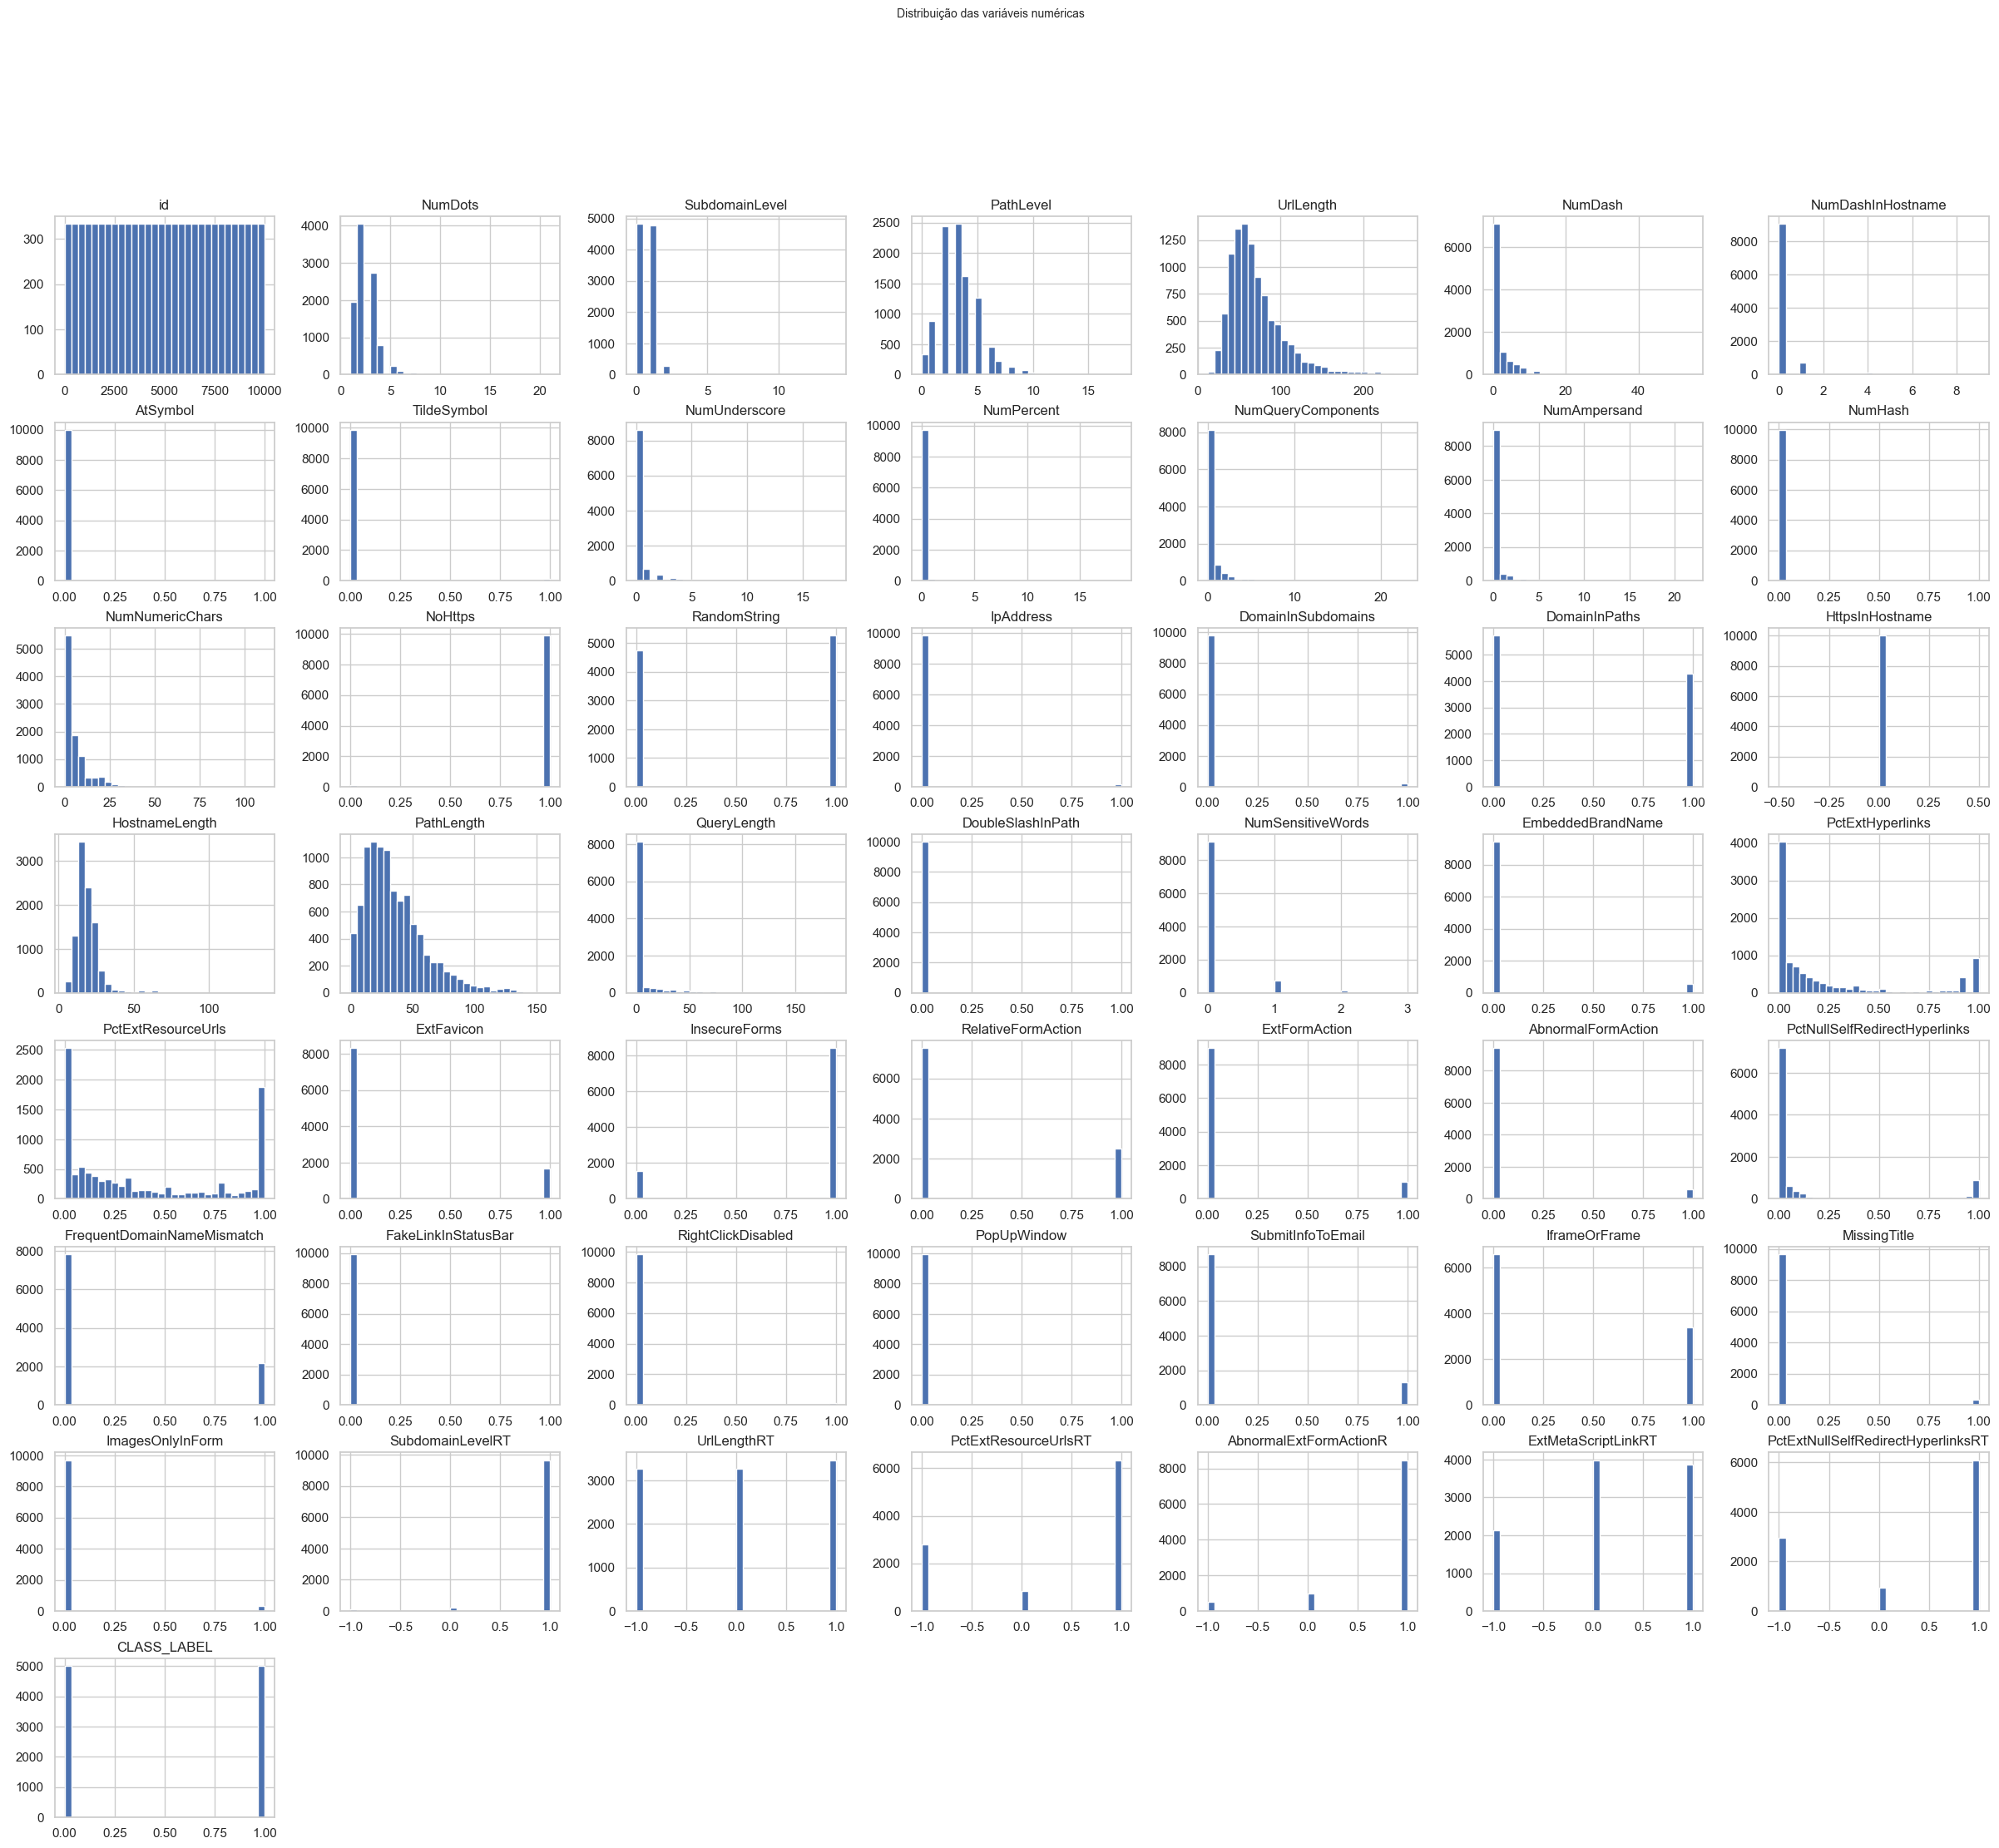

In [56]:
# 4.5.1 Histogramas das variáveis 
df.hist(figsize=(30, 25), bins=30)
plt.suptitle('Distribuição das variáveis numéricas', fontsize=10)
plt.show()

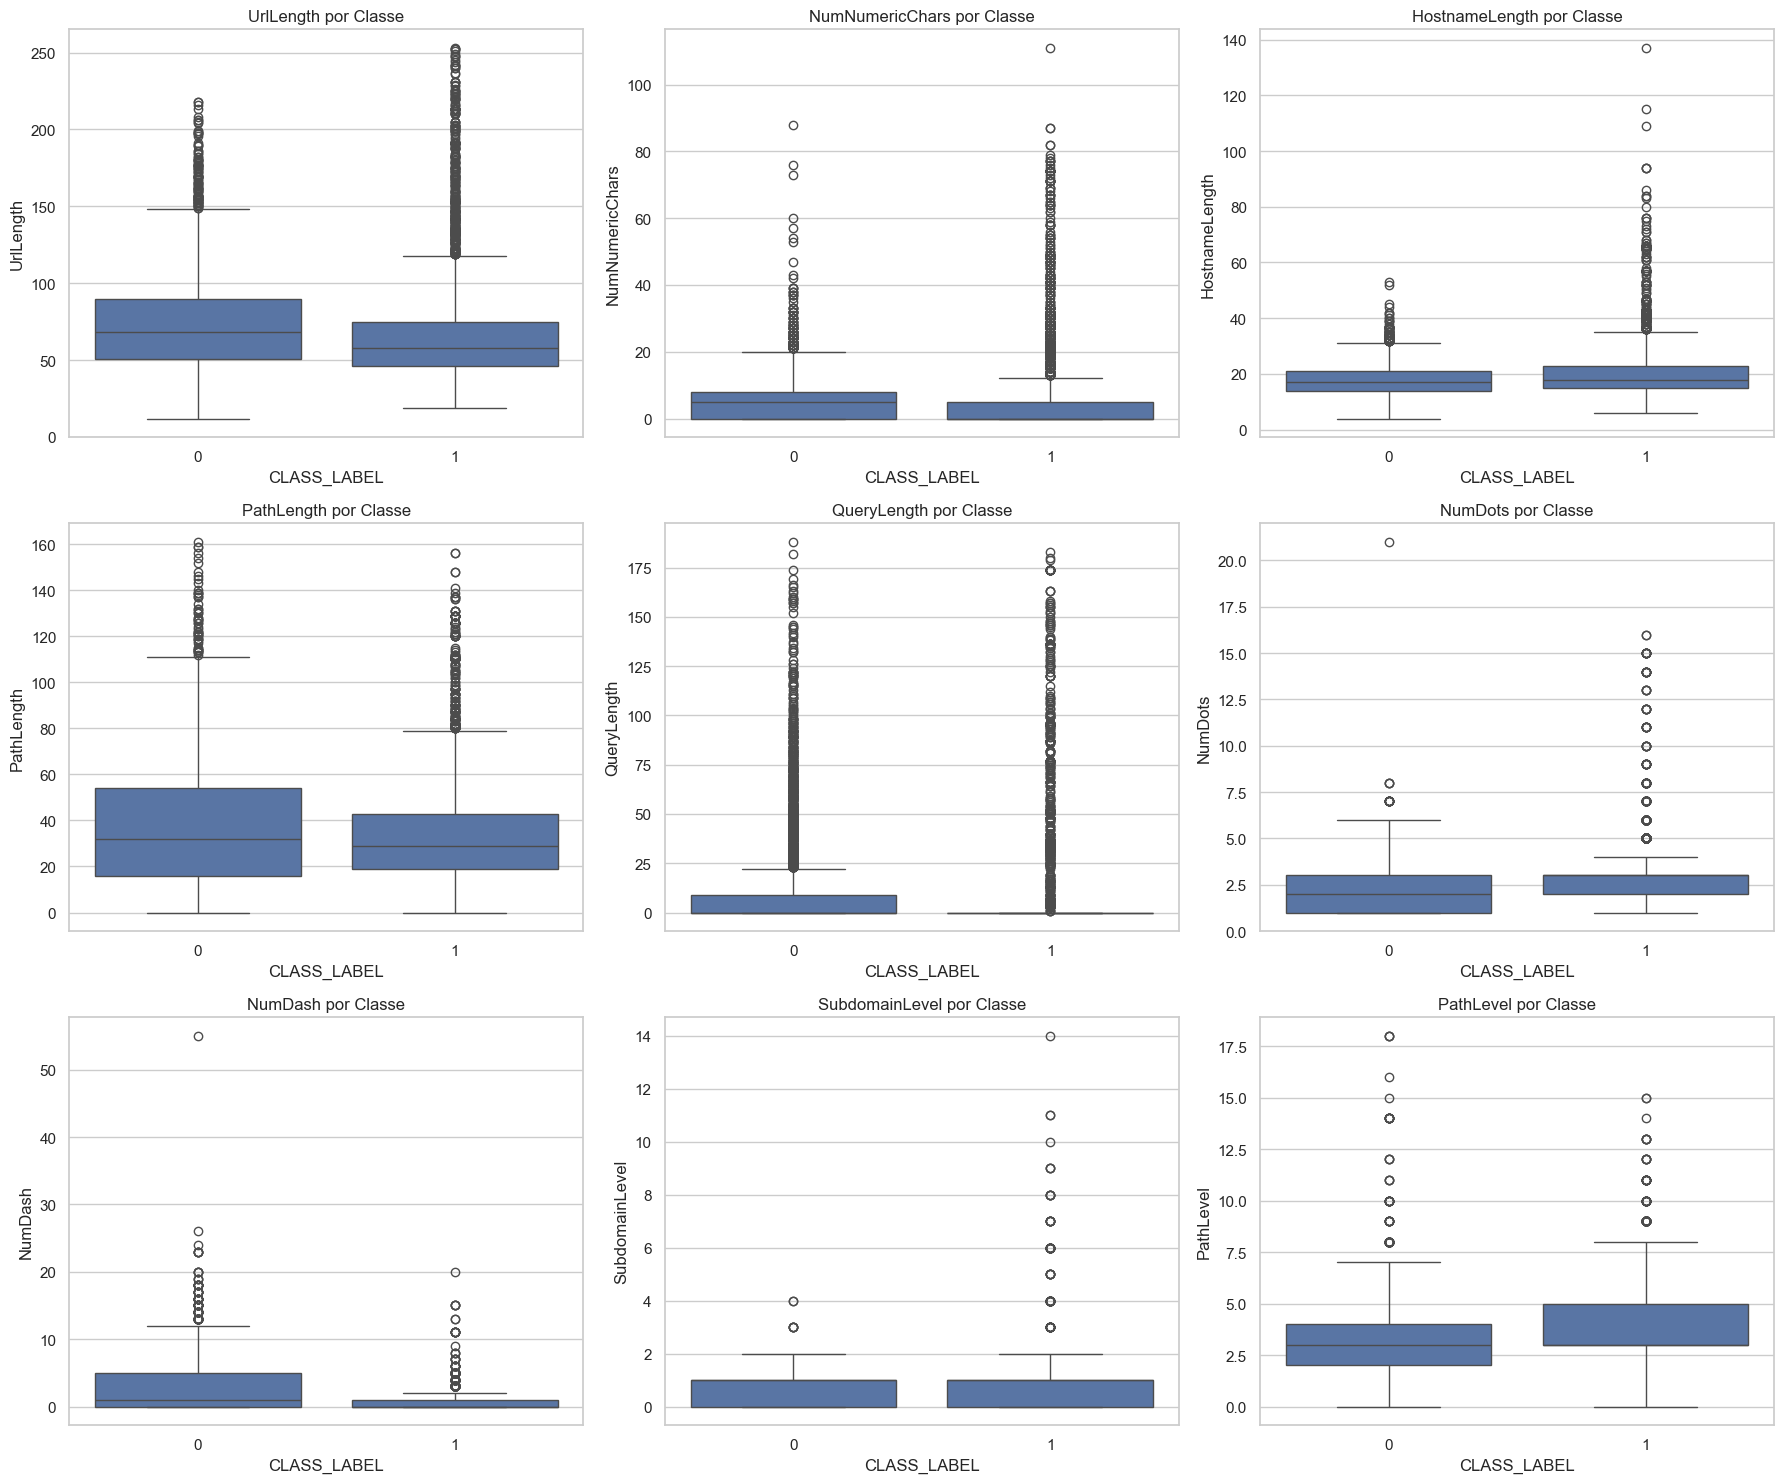

In [ ]:
# 4.5.2 Boxplots por classe
features = [
    'UrlLength',
    'NumNumericChars',
    'HostnameLength',
    'PathLength',
    'QueryLength',
    'NumDots',
    'NumDash',
    'SubdomainLevel',
    'PathLevel',
]

fig, axes = plt.subplots(3, 3, figsize=(18, 15))

axes = axes.flatten()

for i, feature in enumerate(features):

    sns.boxplot(
        x='CLASS_LABEL',
        y=feature,
        data=df,
        ax=axes[i]
    )

    axes[i].set_title(f'{feature} por Classe')

# Remove gráficos vazios
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.show()

#### 4.6 Correlação entre Variáveis

In [ ]:
# 4.6.1 Correlação entre as variáveis
corr_matrix = df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = (
    upper.stack()
    .sort_values(ascending=False)
)

high_corr.head(20)

NumQueryComponents  NumAmpersand                          0.872951
id                  CLASS_LABEL                           0.866025
AbnormalFormAction  AbnormalExtFormActionR                0.818794
NumQueryComponents  QueryLength                           0.811784
PctExtResourceUrls  PctExtResourceUrlsRT                  0.804744
UrlLength           UrlLengthRT                           0.800096
PctExtResourceUrls  ExtMetaScriptLinkRT                   0.765659
NumAmpersand        QueryLength                           0.754427
DomainInSubdomains  SubdomainLevelRT                      0.704292
SubdomainLevel      SubdomainLevelRT                      0.679687
PathLength          UrlLengthRT                           0.668628
PctExtHyperlinks    PctExtNullSelfRedirectHyperlinksRT    0.656196
UrlLength           QueryLength                           0.649204
                    PathLength                            0.643924
                    NumNumericChars                       0.63

Como atributos identificadores não possuem significado semântico relacionado ao comportamento das URLs, essa correlação sugere possível ordenação estrutural do dataset.

Esse comportamento pode introduzir viés e vazamento de informação durante o treinamento dos modelos, permitindo que algoritmos aprendam padrões artificiais associados à ordenação dos registros, em vez de características reais de phishing. Dessa forma, a variável id será removida das etapas posteriores de modelagem.

Foram identificadas correlações elevadas entre alguns atributos originais e suas respectivas versões transformadas ou categorizadas, como `UrlLength` e `UrlLengthRT`, além de `PctExtResourceUrls` e `PctExtResourceUrlsRT`. Esse comportamento sugere que determinadas variáveis derivadas foram construídas a partir de regras heurísticas ou discretizações aplicadas sobre atributos contínuos originais.

**Embora essas variáveis possam fornecer sinais relevantes para classificação, correlações elevadas podem indicar redundância parcial de informação e devem ser consideradas durante as etapas de seleção de atributos e modelagem.**

Além disso, foi observado uma forte associação entre atributos relacionados à estrutura de parâmetros das URLs, como `NumQueryComponents`, `NumAmpersand` e `QueryLength`. Esse comportamento é esperado, uma vez que URLs com maior quantidade de parâmetros tendem a apresentar consultas mais extensas e maior uso de separadores.

Por fim, verifica-se que a variável `UrlLength` apresentou correlação moderada a elevada com atributos como `PathLength`, `QueryLength` e `NumNumericChars`, indicando que URLs mais extensas tendem também a apresentar maior complexidade estrutural. Esse comportamento é compatível com padrões frequentemente observados em ataques de phishing, nos quais URLs artificiais utilizam caminhos longos, parâmetros excessivos e caracteres numéricos como estratégia de mascaramento.



In [57]:
corr_target = (
    df.corr()['CLASS_LABEL']
    .sort_values(ascending=False)
)

print(corr_target)

CLASS_LABEL                           1.000000
FrequentDomainNameMismatch            0.463956
PctNullSelfRedirectHyperlinks         0.342806
InsecureForms                         0.316380
NumDots                               0.294111
PctExtHyperlinks                      0.259728
NumSensitiveWords                     0.255208
PathLevel                             0.229450
AbnormalExtFormActionR                0.185799
UrlLengthRT                           0.169513
HostnameLength                        0.169157
NumDashInHostname                     0.150444
EmbeddedBrandName                     0.141790
IpAddress                             0.132291
MissingTitle                          0.116693
ExtMetaScriptLinkRT                   0.111150
DomainInSubdomains                    0.100452
TildeSymbol                           0.095864
RightClickDisabled                    0.074900
ExtFavicon                            0.069140
PctExtResourceUrlsRT                  0.052089
NumHash      

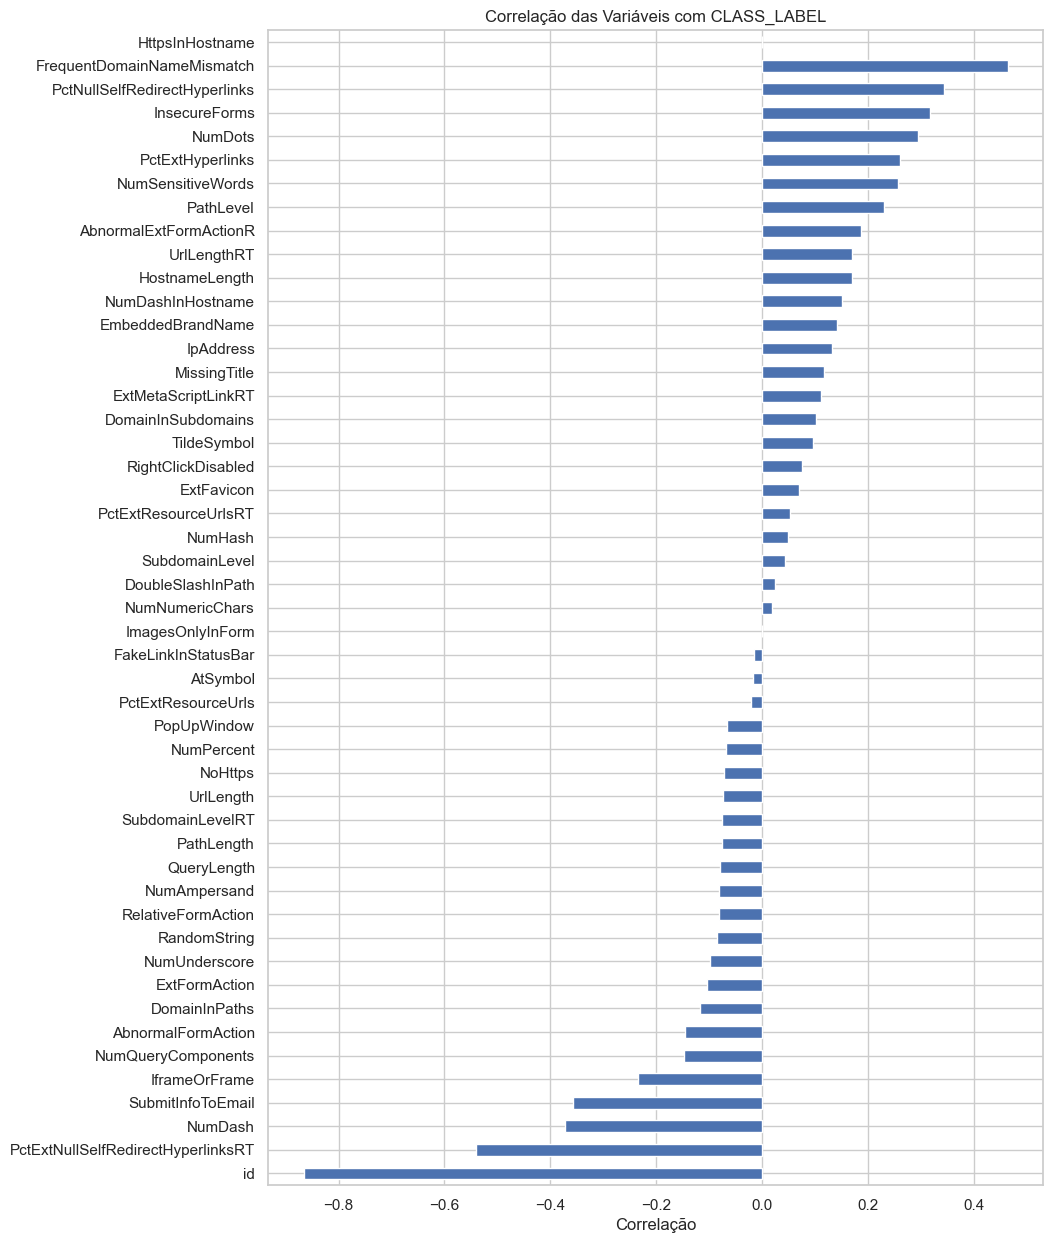

In [58]:
plt.figure(figsize=(10,15))

corr_target.drop('CLASS_LABEL').sort_values().plot(
    kind='barh'
)

plt.title("Correlação das Variáveis com CLASS_LABEL")

plt.xlabel("Correlação")

plt.show()

A análise de correlação com a variável target `CLASS_LABEL` revelou que determinadas features apresentam associação significativa com URLs classificadas como phishing.

Entre os atributos com maior correlação positiva destacam-se `FrequentDomainNameMismatch`, `PctNullSelfRedirectHyperlinks`, `InsecureForms` e `NumDots`, indicando que inconsistências entre domínios, presença de redirecionamentos suspeitos, formulários inseguros e estruturas excessivamente complexas nas URLs estão fortemente associadas a comportamentos maliciosos.

Observa-se também que variáveis relacionadas à presença de recursos externos (`PctExtHyperlinks`) e palavras sensíveis (`NumSensitiveWords`) demonstram relevância estatística para diferenciação entre URLs legítimas e phishing.

Além disso, algumas variáveis derivadas apresentaram correlações negativas significativas com a classe alvo, sugerindo que seus processos de categorização heurística podem ter sido construídos com codificações inversas em relação à representação da variável alvo.

A variável `id` apresentou correlação extremamente elevada com a classe, evidenciando possível ordenação estrutural do dataset e potencial risco de vazamento de informação (data leakage), motivo pelo qual sua utilização em etapas futuras de modelagem deverá ser cuidadosamente avaliada.

Já a variável HttpsInHostname apresentou correlação indefinida (NaN) devido à ausência completa de variabilidade nos dados, assumindo valor constante em todas as observações.

#### 4.8 Insights Extraídos da EDA